# DAY 1 - EDA 및 DAY 2 모델 개발·평가 설계

**문서 범위:** DAY 1의 EDA·설계 근거에 DAY 2 실행 결과를 연결해 갱신한 문서다. 아래 셀은 EDA와 분할 준비를 수행하며, 최종 학습·평가는 [DAY 2 노트북](30-ESSHealth-Day2-Modeling.ipynb)에서 수행한다. 현재 최종 모델은 로그 분산 하나를 사용하는 RBF SVR, Batch 2 MAPE는 28.08%다.

- 대상 Dataset: **제공 폴더의 Batch 1 + Batch 2 + Batch 3**
- 다섯 EDA 질문을 확인하고 배치 간 특징을 비교한다.
- 확인한 내용으로 변수와 후보 모델을 제안하고, DAY 2의 평가 방법을 정한다.

**평가 기준 반영:** 그래프의 목적, 확인한 사실, 모델 선택 이유를 연결한다. 관측한 결과와 확인하지 못한 원인을 구분하고, 선택 이유를 직접 설명할 수 있도록 정리한다.

**이번 분석의 차별점:** 충전 조건만 사용할 때와 초기 ΔQ 정보를 추가할 때를 같은 방법으로 비교한다. 변수를 만들었다는 사실에 그치지 않고 실제 오차가 줄었는지 확인한다. 도움이 되지 않은 변수도 그 결과를 그대로 설명한다. 기존의 세 배치 성능 실험은 탐색 결과로 구분하고, 최종 선택은 Batch 1 개발 자료의 MAPE로 확인한다.

## 입력 데이터 설명

| 과제 배치 | 제공 파일 | 원본 셀 | 유효 수명값 EDA | 모델 사용 가능 |
|---|---|---:|---:|---:|
| Batch 1 | `2017-05-12_batchdata_updated_struct_errorcorrect.mat` | 46 | 46 | 36 |
| Batch 2 | `2018-02-20_batchdata_updated_struct_errorcorrect.mat` | 47 | 39 | 39 |
| Batch 3 | `2018-04-12_batchdata_updated_struct_errorcorrect.mat` | 46 | 44 | 40 |

파일은 모두 `/Users/jang/Documents/data-science/skala-ds/90-MiniProject/data/data-30`에서 읽었다. `2018-04-03_varcharge`는 이번 분석에서 제외했다. **과제의 Batch 2는 제공된 `2018-02-20`으로 사용한다.** 논문 저자 코드의 `2017-06-30`과 구분하며, 그 파일의 후속 연결 규칙을 이 Batch 2에 적용하지 않았다.

배터리 한 개가 예측 표본 한 개이고, 같은 셀의 사이클 기록은 반복 측정이다. 원본 139개 중 수명값이 없는 Batch 2의 8개와 Batch 3의 2개는 목표값 분포·상관·모델에서 제외했다. 유효 수명값이 있는 129개 셀의 사이클 기록은 108,426행이다. 이를 독립 배터리 108,426개로 취급하지 않는다.

**원자료 EDA와 모델 평가를 구분:** Batch 1 원본의 그림을 유지하기 위해 수명값 46개를 그대로 분포에 표시했다. 다만 저자 정리 코드에서 후속 실험 연결 대상인 5개와 수명 종료에 도달하지 않은 5개는 이 파일만으로 최종 수명을 확정하기 어려워 모델에서 제외했다. Batch 3은 수명값 결측 2개 외에 저자 코드의 제외 대상 4개를 모델에서 제외했다. 이 네 셀은 제공된 수명값 분포에는 표시한다. 따라서 **분포 EDA는 129개, 신호 분석과 기존 탐색은 115개**다. DAY 2에서는 이 중 **Batch 1의 36개만 학습 후보 표본**으로 사용하고, Batch 2의 39개는 최종 Test로 둔다. Batch 3는 EDA 비교와 고정 모델의 추가 평가에 사용하며 모델 선택에는 넣지 않았다. 제외 목록과 이유는 `data_audit.csv`에 남겼다. [저자 데이터 정리 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/Load%20Data.ipynb)

**X:** 100사이클까지의 충전 조건과 측정값. **y:** `cycle_life`, 최종 수명 사이클 수. 논문은 공칭 용량 1.1 Ah의 80%인 0.88 Ah를 수명 종료 기준으로 사용한다. [원 논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)


### 수명 예측을 어디에 활용할 것인가?

배터리 수명을 끝까지 시험하려면 많은 시간이 필요하다. 초기 측정으로 예상 수명을 얻으면 장기 시험 대상이나 충전 조건을 검토하는 데 도움을 줄 수 있다. 이번 분석은 **초기 100사이클로 최종 수명을 예측해 시험 판단에 참고하는 것**을 목적으로 한다. 예측만으로 교체·사용 여부를 자동으로 결정한다고 가정하지 않는다. [원 논문의 연구 목적](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

100사이클은 이번 회귀 과제와 논문 비교의 기준이며, ΔQ100-10을 계산할 수 있는 시점이다. 초기에 전체 용량 변화가 작아도 전압별 변화가 수명과 연결되는지 확인한다. 이 시점이 모든 상황에서 가장 빠르거나 최적이라고 확정한 것은 아니다.

### 누락·비정상 측정값은 어떻게 처리하는가?

아래 표는 수명값이 있는 129개 셀의 초기 2~100사이클, 각 측정 항목 12,771개에 대한 점검이다. 0 자리표시자·비정상 값과 정리 후 셀 평균의 결측을 구분했다.

| 측정값 | 초기 2~100사이클의 비정상·결측 측정 수 | 정리 후 셀 평균 결측 수 |
|---|---:|---:|
| QD | 2 / 12771 | 0 / 129 |
| IR | 605 / 12771 | 6 / 129 |
| Tavg | 0 / 12771 | 0 / 129 |
| Tmax | 0 / 12771 | 0 / 129 |
| chargetime | 13 / 12771 | 0 / 129 |

QD는 0.01~1.32 Ah 밖의 값을 분리했다. IR·온도·충전 시간은 0 이하 또는 비정상 값을 분리했고, 충전 시간 60분 초과도 탐색 기준으로 분리했다. 이 기준은 값의 품질을 점검하기 위한 것이며 수명이 짧다는 이유로 셀을 제거한 기준이 아니다. IR은 정리 후 평균이 없는 셀이 6개다. 현재 모델용 Batch 1의 36개 셀에서는 표의 다섯 평균값에 결측이 없다.

DAY 2에서 입력 결측이 생기면 학습 자료의 중앙값으로 채운다. 중앙값과 변수 크기 조정은 각 CV 학습 부분에서만 계산한다. 목표값 `cycle_life`의 결측은 임의로 채우지 않는다.

**DAY 2 평가의 기준:** Batch 1만 개발에 사용하고, Batch 1 Hold-out과 Batch 2 최종 Test를 MAPE로 평가한다. 아래의 EDA와 기존 MAE 실험은 모델 후보를 제안한 근거다. DAY 2 학습·평가는 완료했으며 Train CV 15.40%, Valid 11.87%, Batch 2 Test 28.08%, Batch 3 추가 Test 18.85%다. 수치와 Gap은 아래 최신 성능 표 및 DAY 2의 결과를 따른다.


## Question


재실행: numpy, pandas, matplotlib, scikit-learn 필요. DAY 2에서 생성한 results/three_batches_eda_data.json.gz를 사용한다. 기존 MAE 실험과 DAY 2 분할 준비를 구분한다.

In [1]:
from pathlib import Path
import gzip,json,re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold,GridSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
BASE = PROJECT_ROOT / 'results/eda'
FIGURE_DIR = PROJECT_ROOT / 'results/figures'
BASE.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
cache_path = PROJECT_ROOT / 'results/three_batches_eda_data.json.gz'
with gzip.open(cache_path, 'rt', encoding='utf-8') as f:
    batteries=json.load(f)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':12,'axes.spines.top':False,'axes.spines.right':False})
palette={1:'#238a98',2:'#d28b33',3:'#8463ad'}
def show_save(fig,name):
    fig.savefig(FIGURE_DIR/name,dpi=170,bbox_inches='tight')
    plt.show()
records=[];features=[];curves={}
for b in batteries:
    s=pd.DataFrame(b['summary']).rename(columns={'QDischarge':'QD','QCharge':'QC'})
    s['cell_id']=b['cell_id'];s['batch']=b['batch'];s['cycle_life']=b['cycle_life'];s['policy']=b['policy']
    records.append(s)
    e=s[s.cycle.between(2,100)].copy()
    e.loc[~e.QD.between(.01,1.32),['QD','QC']]=np.nan
    policy=b['policy'].removesuffix('-newstructure')
    if not policy.endswith('C'):policy+='C'
    row={'cell_id':b['cell_id'],'batch':b['batch'],'cycle_life':b['cycle_life'],'policy':policy,'model_eligible':b['model_eligible'],'model_exclusion_reason':b['model_exclusion_reason']}
    for field in ['QD','IR','Tavg','Tmax','chargetime']:
        values=e[field].where(e[field]>0)
        if field=='chargetime':values=values.where(values<=60)
        row['mean_'+field]=float(values.mean())
    match=re.fullmatch(r'([\d.]+)C\(([\d.]+)%\)-([\d.]+)C?',policy)
    if not match:raise ValueError(b['policy'])
    c1,switch,c2=map(float,match.groups())
    row.update(C1=c1,C2=c2,SOC_switch=switch)
    v=np.asarray(b['Vdlin']);q10=np.asarray(b['Qdlin']['10']);q100=np.asarray(b['Qdlin']['100'])
    assert v.shape==q10.shape==q100.shape==(1000,) and np.isfinite(q10).all() and np.isfinite(q100).all()
    delta=q100-q10
    row['dq_log_variance']=float(np.log10(np.var(delta)))
    # Only two engineered model features: log variance and the fixed voltage-band difference.
    row['dq_band_gap']=float(delta[(v>=2.8)&(v<=3.1)].mean()-delta[(v>=2.0)&(v<=2.5)].mean())
    curves[b['cell_id']]=(v,delta)
    features.append(row)
df=pd.concat(records,ignore_index=True);feat=pd.DataFrame(features)
assert feat.groupby('batch').size().tolist()==[46,39,44]
assert len(feat)==129 and not feat.cell_id.duplicated().any()
assert np.isfinite(feat[['cycle_life','dq_log_variance','dq_band_gap']].to_numpy()).all()
model_feat=feat[feat.model_eligible].copy().reset_index(drop=True)
assert model_feat.groupby('batch').size().tolist()==[36,39,40]
assert len(model_feat)==115
feat.to_csv(BASE/'cell_features.csv',index=False)
print('Curated cells by batch:',feat.groupby('batch').size().to_dict())
print('Cycle rows:',len(df),'life range:',feat.cycle_life.min(),feat.cycle_life.max())

Curated cells by batch: {1: 46, 2: 39, 3: 44}
Cycle rows: 108426 life range: 392.0 1935.0


### 1. Cycle Life 분포는 어떻게 생겼는가?

**확인 목적:** 기존 그림으로 원자료 분포를 확인한 뒤, 배치 간 수명 차이를 비교한다. 원래 노트북의 **Histogram + Box Plot**을 유지했다.



**기존 그림 해석:** Batch 1 원본 46개 셀의 평균은 **844.7사이클**, 중앙값은 **858.5사이클**이다. 따라서 제공 이미지의 `mean = 845`와 일치한다. 대부분 700~900사이클 부근에 있고 범위는 534~1,227사이클이다. 이 그림은 Batch 1만 표시하며, 전체 세 배치의 분포는 아니다.



| 배치 | 셀 수 | 평균 수명 | 중앙값 | 단수명 <500 | 장수명 >1,000 |
|---|---:|---:|---:|---:|---:|
| Batch 1 | 46 | 844.7 | 858.5 | 0개 (0.0%) | 10개 (21.7%) |
| Batch 2 | 39 | 565.7 | 472.0 | 28개 (71.8%) | 3개 (7.7%) |
| Batch 3 | 44 | 1059.7 | 1005.5 | 0개 (0.0%) | 23개 (52.3%) |

**비교 방법:** 배치별 히스토그램을 나란히 분리했다. 막대 구간은 100사이클이며, 세 히스토그램의 가로축과 세로축 범위를 동일하게 맞췄다. 점선은 각 배치의 평균이다. 오른쪽 Box Plot으로 중앙값과 분포 폭을 함께 비교한다.

**배치 비교 해석:** Batch 2 평균은 565.7사이클이고 단수명(<500) 비율이 71.8%다. Batch 3 평균은 1,059.7사이클이고 장수명(>1,000) 비율이 52.3%다. 전체 유효 수명값은 392~1,935사이클로, 과제에서 제시한 약 150~2,300 범위를 전부 채우지는 않는다. 제공된 파일의 실제 범위를 보고했다.

가장 짧은 셀은 **b2c19, 392사이클, `6C(60%)-3C`**다. 낮은 수명값이라는 이유만으로 삭제하지 않았다. Batch 2의 단수명 셀이 여러 개이며, 충전 조건과 용량 곡선을 함께 확인해야 한다. 고속 충전이 이 셀의 짧은 수명을 단독으로 일으켰다고 확정할 수는 없다. 반면 결측 수명이나 종료 전 중단된 실험 기록은 목표값 신뢰성 때문에 구분한다.

**시사점:** 기존 그래프 형태를 유지하면서 배치 차이를 추가로 설명한다. DAY 2에서는 Batch 1 안에서 충전 프로토콜을 구분해 CV와 Hold-out을 구성하고, Batch 2를 최종 Test로 사용한다. 원자료의 분포와 최종 수명이 확인된 모델 표본을 구분한다.


       count     mean  median    min     max  short_n  long_n  short_pct  long_pct
batch                                                                             
1         46   844.72   858.5  534.0  1227.0        0      10       0.00     21.74
2         39   565.74   472.0  392.0  1186.0       28       3      71.79      7.69
3         44  1059.66  1005.5  541.0  1935.0        0      23       0.00     52.27
Shortest valid cells:
cell_id  batch  cycle_life      policy
  b2c19      2       392.0  6C(60%)-3C
   b2c6      2       393.0 3.6C(9%)-5C
  b2c15      2       396.0 3.6C(9%)-5C


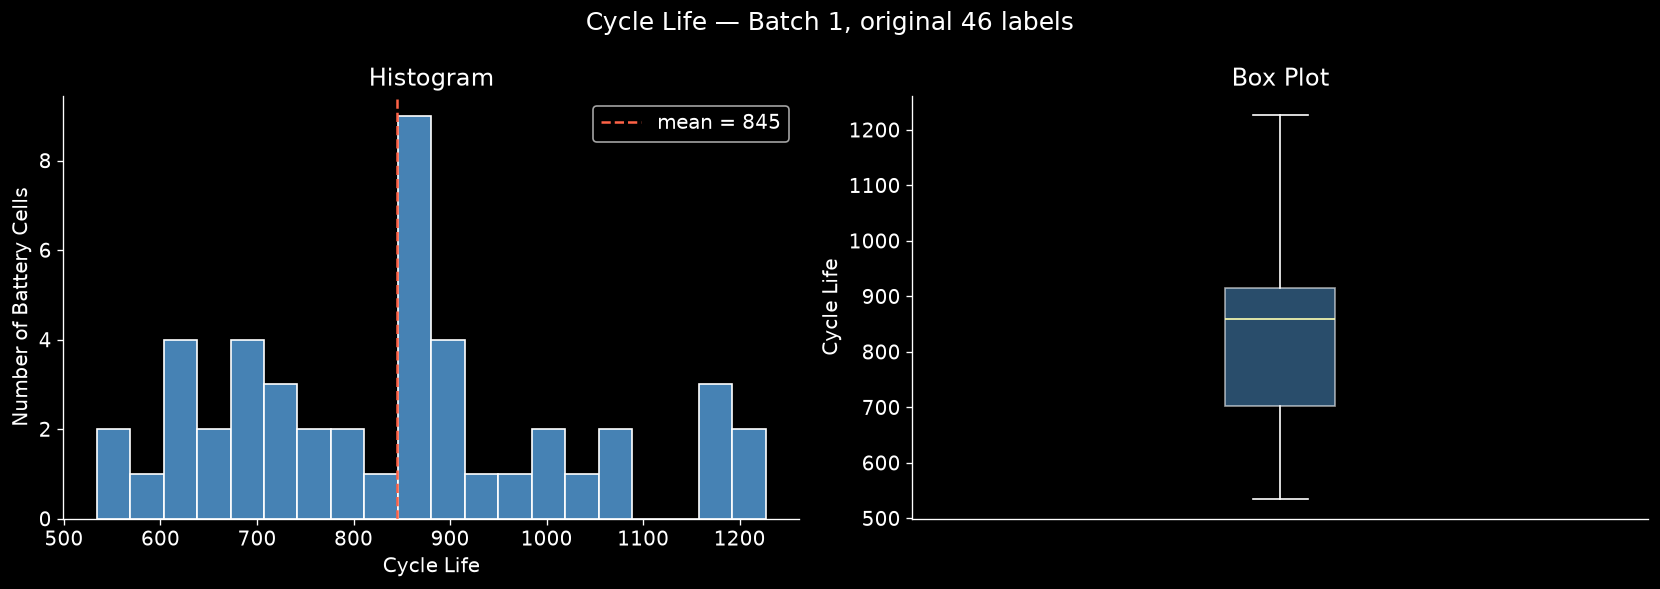

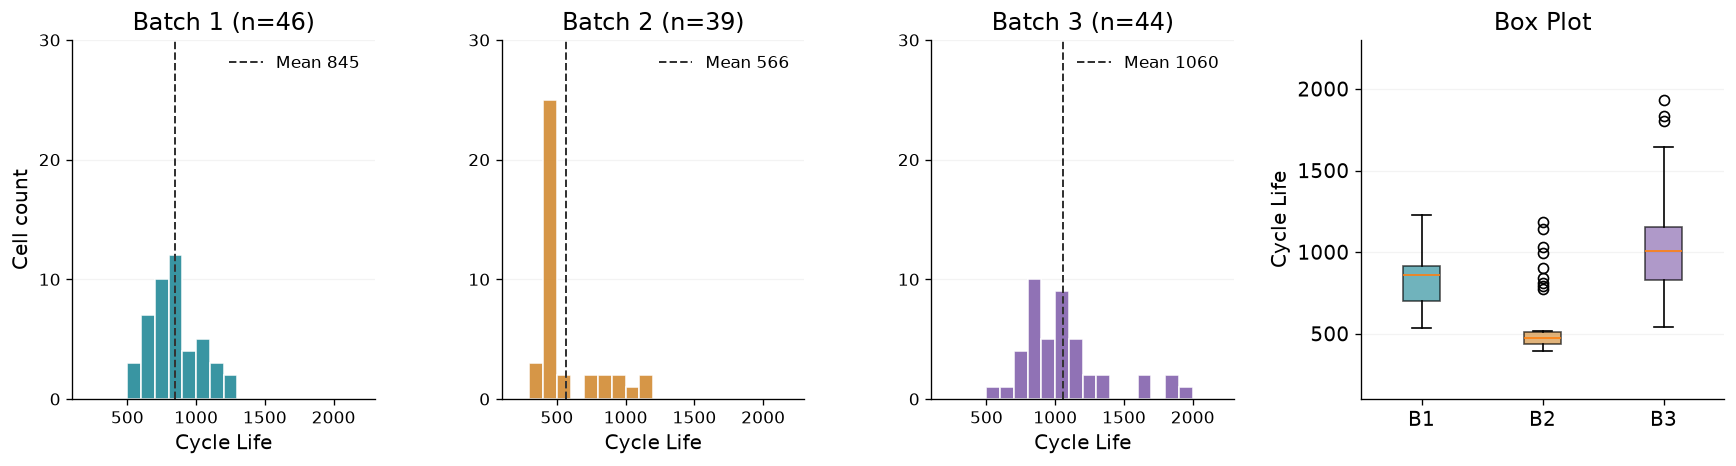

In [2]:
life_stats=feat.groupby('batch').cycle_life.agg(['count','mean','median','min','max'])
life_stats['short_n']=feat.groupby('batch').cycle_life.apply(lambda s:(s<500).sum())
life_stats['long_n']=feat.groupby('batch').cycle_life.apply(lambda s:(s>1000).sum())
life_stats['short_pct']=life_stats.short_n/life_stats['count']*100
life_stats['long_pct']=life_stats.long_n/life_stats['count']*100
life_stats.to_csv(BASE/'batch_life_summary.csv')
# Preserve the original notebook's Histogram + Box Plot for Batch 1 (all 46 raw labels).
with plt.style.context('dark_background'):
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    original=feat[feat.batch==1].cycle_life
    axes[0].hist(original,bins=20,color='steelblue',edgecolor='white')
    axes[0].axvline(original.mean(),color='tomato',ls='--',label=f'mean = {original.mean():.0f}')
    axes[0].set(title='Histogram',xlabel='Cycle Life',ylabel='Number of Battery Cells');axes[0].legend()
    axes[1].boxplot(original,patch_artist=True,boxprops=dict(facecolor='steelblue',alpha=.6))
    axes[1].set(title='Box Plot',ylabel='Cycle Life',xticks=[])
    fig.suptitle('Cycle Life — Batch 1, original 46 labels',fontsize=15)
    fig.tight_layout();show_save(fig,'q1_original_style.png')
# Non-overlapping histograms: identical bins and common count/life scales.
fig=plt.figure(figsize=(14.8,4.4))
grid=fig.add_gridspec(1,4,width_ratios=[1,1,1,1.2],wspace=.4)
axes=[fig.add_subplot(grid[0,i]) for i in range(4)]
bins=np.arange(100,2401,100)
max_count=max(np.histogram(feat[feat.batch==bi].cycle_life,bins=bins)[0].max() for bi in [1,2,3])
count_limit=int(np.ceil((max_count+1)/5)*5)
for bi,ax in zip([1,2,3],axes[:3]):
    values=feat[feat.batch==bi].cycle_life
    counts,_=np.histogram(values,bins=bins)
    assert counts.sum()==len(values)
    ax.hist(values,bins=bins,color=palette[bi],edgecolor='white',alpha=.9)
    ax.axvline(values.mean(),color='#333333',ls='--',lw=1.2,label=f'Mean {values.mean():.0f}')
    ax.set(title=f'Batch {bi} (n={len(values)})',xlabel='Cycle Life',xlim=(100,2300),ylim=(0,count_limit),xticks=[500,1000,1500,2000],yticks=range(0,count_limit+1,10))
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=10,frameon=False,loc='upper right')
    ax.grid(axis='y',alpha=.15);ax.set_axisbelow(True)
axes[0].set_ylabel('Cell count')
box=axes[3].boxplot([feat[feat.batch==i].cycle_life for i in [1,2,3]],patch_artist=True)
for patch,i in zip(box['boxes'],[1,2,3]):patch.set_facecolor(palette[i]);patch.set_alpha(.65)
axes[3].set(title='Box Plot',ylabel='Cycle Life',xticks=[1,2,3],xticklabels=['B1','B2','B3'],ylim=(100,2300))
axes[3].grid(axis='y',alpha=.15);axes[3].set_axisbelow(True)
fig.subplots_adjust(left=.05,right=.98,bottom=.18,top=.86)
show_save(fig,'q1_batch_life.png')
print(life_stats.round(2).to_string())
shortest=feat.nsmallest(3,'cycle_life')[['cell_id','batch','cycle_life','policy']]
print('Shortest valid cells:');print(shortest.to_string(index=False))

### 2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?

**확인 목적:** 용량이 일정하게 줄어드는지, 수명 말기에 감소가 빨라지는지 확인한다. 배치마다 같은 축으로 표시했다. 0 Ah 자리표시자와 1.32 Ah를 넘는 큰 스파이크는 그래프에서 분리했다.



**확인한 내용과 해석:** 초기 용량이 유지되거나 조금 증가하는 셀이 많다. 100사이클 용량이 2사이클보다 큰 셀은 Batch 1 **42/46**, Batch 2 **25/39**, Batch 3 **37/44**다. 초기 전체 용량이 비슷하더라도 이후 감소와 수명은 다르다. 전체 구간을 일정한 직선 감소로 설명하기 어렵다.



배치별 중간 수명 셀의 곡선에 직선 두 개를 맞춰 감소가 가팔라지는 **Knee point 후보**를 표시했다. 후보는 Batch 1 약 **628**, Batch 2 약 **365**, Batch 3 약 **843사이클**이다. 이는 곡선의 꺾임을 쉽게 보는 추정값이며 물리적 열화 시작점을 확정한 값은 아니다.

**시사점:** 초기 용량 하나만으로 수명을 판단하기 어렵다. 전압별 변화인 ΔQ를 확인한다. **Knee는 전체 곡선으로 계산했으므로 100사이클 예측 입력에서 제외한다.** 마지막 용량과 전체 기록 길이도 같은 이유로 제외한다.


 batch cell_id  knee_candidate  slope_before  slope_after
     1   b1c28      627.595918     -0.000070    -0.000675
     2   b2c16      364.575510     -0.000181    -0.001504
     3    b3c0      843.428571     -0.000063    -0.000794


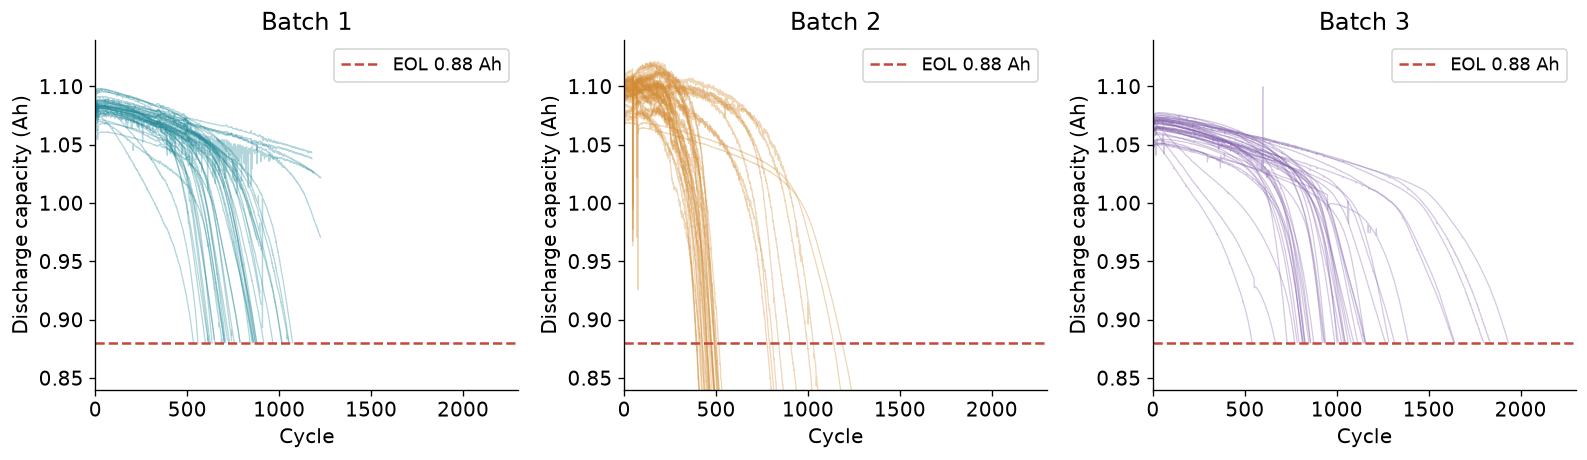

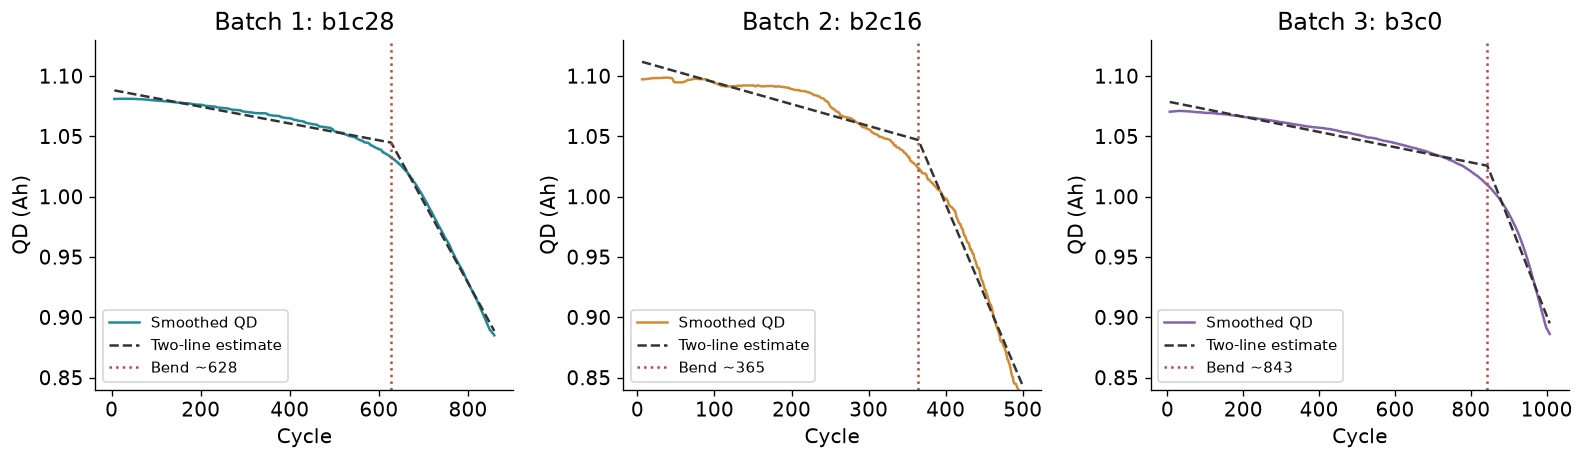

In [3]:
def valid_capacity(sub):return sub.QD.where(sub.QD.gt(0)&sub.QD.le(1.32))
fig,axes=plt.subplots(1,3,figsize=(13.4,4))
for bi,ax in enumerate(axes,1):
    for cid,sub in df[df.batch==bi].groupby('cell_id'):
        ax.plot(sub.cycle,valid_capacity(sub),color=palette[bi],lw=.75,alpha=.35)
    ax.axhline(.88,color='#c3473b',ls='--',label='EOL 0.88 Ah')
    ax.set(title=f'Batch {bi}',xlabel='Cycle',ylabel='Discharge capacity (Ah)',ylim=(.84,1.14),xlim=(0,2300))
    ax.legend(fontsize=11)
fig.tight_layout();show_save(fig,'q2_degradation.png')

# A visual change-point estimate uses the full curve for EDA only. It is not a model feature.
knee_rows=[];representatives={}
fig,axes=plt.subplots(1,3,figsize=(13.4,4))
for bi,ax in enumerate(axes,1):
    candidates=feat[feat.batch==bi].sort_values('cycle_life')
    cid=candidates.iloc[len(candidates)//2].cell_id;representatives[bi]=cid
    sub=df[(df.cell_id==cid)&(df.cycle>5)].copy();sub['QD']=valid_capacity(sub)
    sub=sub.dropna(subset=['QD']);t=sub.cycle.to_numpy();y=sub.QD.rolling(21,center=True,min_periods=1).median().to_numpy()
    tc=t/t.max();best=None
    for knot in np.linspace(.2,.85,50):
        X=np.column_stack([np.ones(len(t)),tc,np.maximum(tc-knot,0)])
        beta=np.linalg.lstsq(X,y,rcond=None)[0];fit=X@beta;sse=np.sum((y-fit)**2)
        if best is None or sse<best[0]:best=(sse,knot,beta,fit)
    sse,knot,beta,fit=best;kc=knot*t.max()
    ax.plot(t,y,color=palette[bi],label='Smoothed QD')
    ax.plot(t,fit,color='#333333',ls='--',label='Two-line estimate')
    ax.axvline(kc,color='#c3473b',ls=':',label=f'Bend ~{kc:.0f}')
    ax.set(title=f'Batch {bi}: {cid}',xlabel='Cycle',ylabel='QD (Ah)',ylim=(.84,1.13))
    ax.legend(fontsize=9)
    knee_rows.append({'batch':bi,'cell_id':cid,'knee_candidate':kc,'slope_before':beta[1]/t.max(),'slope_after':(beta[1]+beta[2])/t.max()})
fig.tight_layout();show_save(fig,'q2_knee_examples.png')
pd.DataFrame(knee_rows).to_csv(BASE/'knee_eda_only.csv',index=False)
print(pd.DataFrame(knee_rows).round(6).to_string(index=False))

### 3. ΔQ(V) 곡선 - 초기 사이클에서 차이가 보이는가?

**확인 목적:** 전체 용량 변화가 작아도 전압별 변화가 다른지 확인한다. 같은 1,000개 전압 점에서 **ΔQ(V)=Q100(V)-Q10(V)**를 계산했다.



**그래프 읽는 방법:** Short는 수명 500사이클 미만, Long은 1,000사이클 초과다. Batch 1·3의 Short는 각각 0개여서 곡선이 없다. Batch 2의 주황색 곡선은 Short 28개, 청록색은 Long 3개다. 진한 선은 집단 평균, 옅은 선은 개별 셀이다. 세 패널의 가로·세로 축 범위는 동일하며 500~1,000사이클 셀은 이 그림에서 제외한다.

**확인한 내용과 해석:** 장수명과 단수명 셀의 곡선은 변화 폭이 다르다. Batch 2에는 두 집단이 모두 있어 배치 안에서도 비교할 수 있다. Batch 1·3에는 500사이클 미만 셀이 없어 극단 집단을 비교할 때 배치 차이도 섞인다. 그림은 제공된 유효 수명값 기준이며, 모델·상관 분석에서는 앞서 설명한 제외를 적용한다.

신호 분석 대상 115개 셀에서 ΔQ 로그 분산과 수명의 상관은 Batch 1 **-0.827**, Batch 2 **-0.902**, Batch 3 **-0.742**다. 각 배치 안에서도 값이 큰 셀일수록 짧은 수명과 연결된다. 분산은 전압 전체에서 ΔQ 값이 얼마나 퍼지는지 요약한다.

**시사점:** ΔQ 로그 분산을 첫 번째 파생변수로 만든다. 변화 위치도 도움이 되는지 확인하기 위해 전압 구간 차이를 두 번째 후보로 만든다. 최종 채택은 상관뿐 아니라 Batch 1 개발 자료의 MAPE 개선으로 판단한다.


All log-var r= -0.857 band-gap r= 0.818
1 log-var r= -0.827 band-gap r= 0.829
2 log-var r= -0.902 band-gap r= 0.885
3 log-var r= -0.742 band-gap r= 0.747


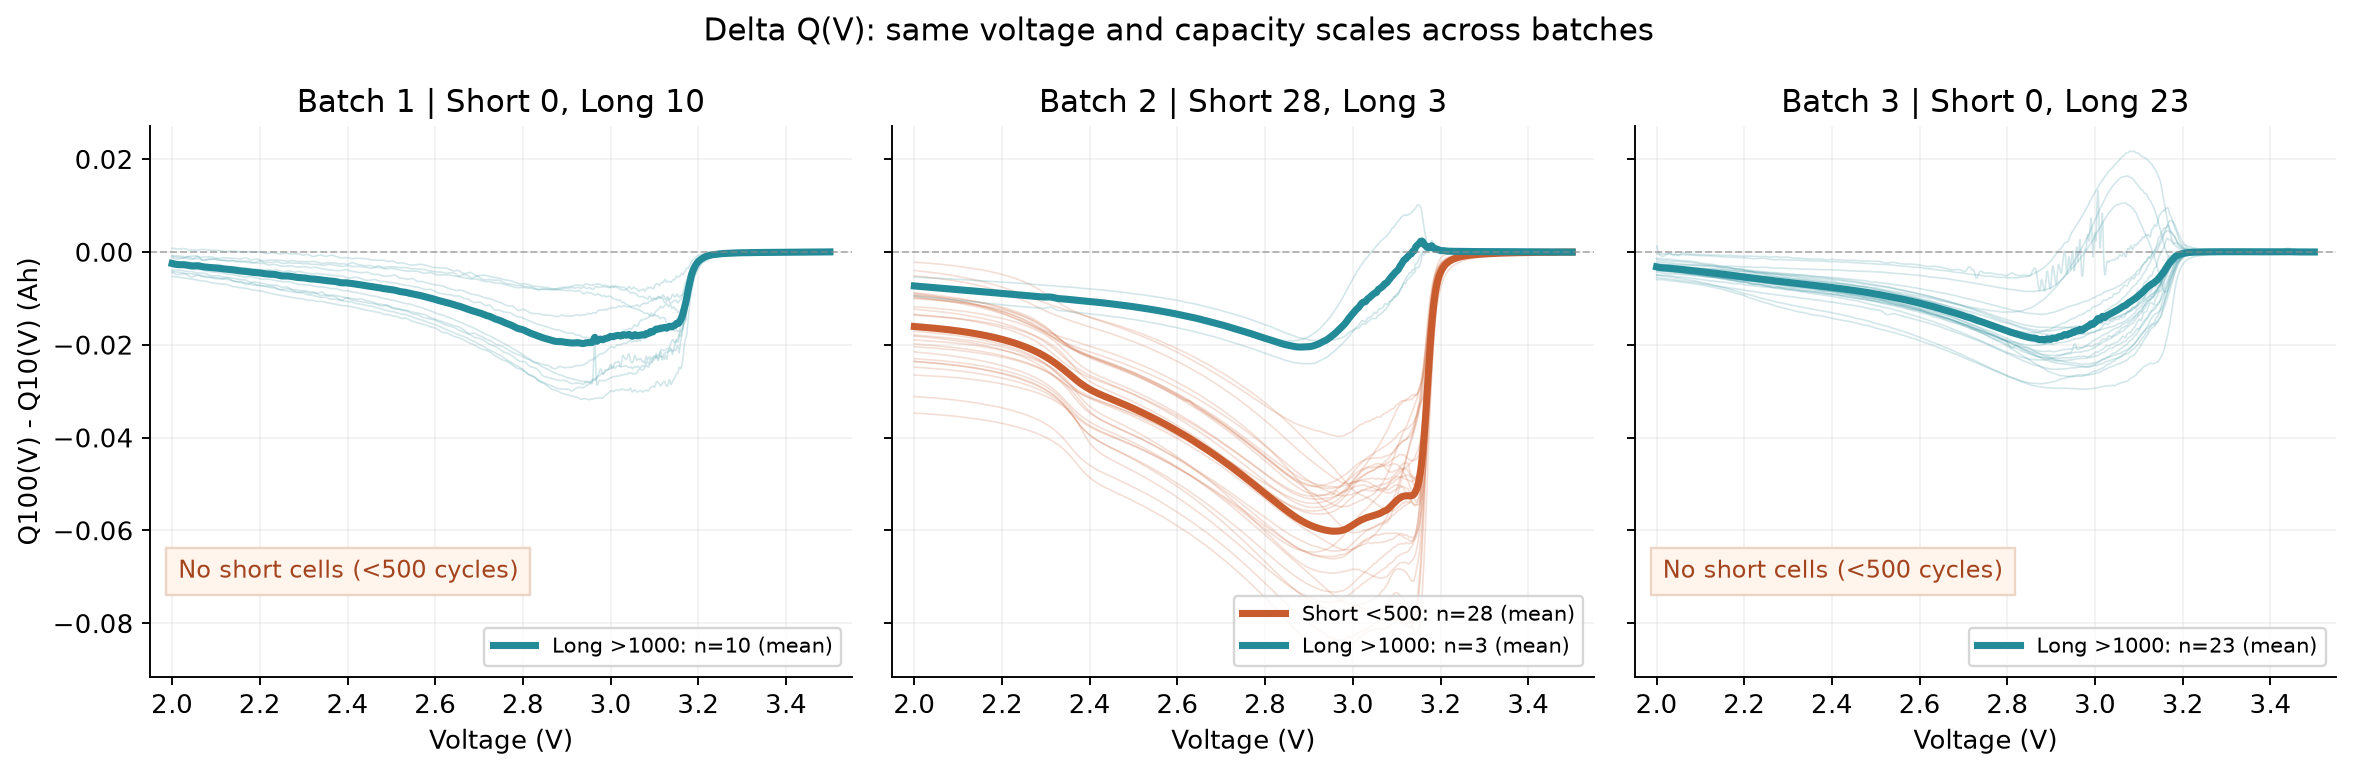

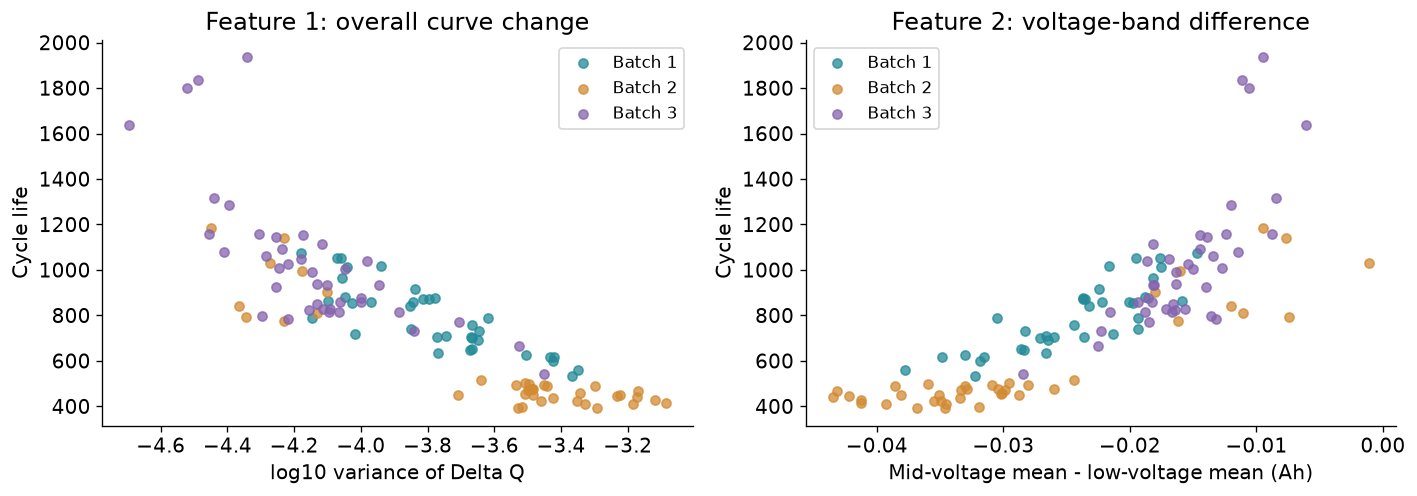


Delta Q group counts: Batch 1 Short 0 / Long 10; Batch 2 Short 28 / Long 3; Batch 3 Short 0 / Long 23.


In [4]:
# Short: cycle_life < 500; Long: cycle_life > 1000.
# A group with no cells has no curve; show its absence explicitly.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
group_counts = []
for bi, ax in enumerate(axes, 1):
    group = feat[feat.batch == bi]
    short_n = int((group.cycle_life < 500).sum())
    long_n = int((group.cycle_life > 1000).sum())
    group_counts.append({'batch': bi, 'short_n': short_n, 'long_n': long_n})
    for label, mask, color in [
        ('Short <500', group.cycle_life < 500, '#c95c2e'),
        ('Long >1000', group.cycle_life > 1000, '#238a98')
    ]:
        selected = group[mask]
        if selected.empty:
            continue
        values = []
        for cid in selected.cell_id:
            v, d = curves[cid]
            order = np.argsort(v)
            ax.plot(v[order], d[order], color=color, lw=.7, alpha=.2)
            values.append(d)
        mean = np.mean(values, axis=0)
        ax.plot(v[order], mean[order], color=color, lw=3,
                label=f'{label}: n={len(selected)} (mean)')
    if short_n == 0:
        ax.text(.04, .18, 'No short cells (<500 cycles)', transform=ax.transAxes,
                color='#a3441e', fontsize=10,
                bbox=dict(facecolor='#fff5ed', edgecolor='#edd5c5', pad=5))
    ax.axhline(0, color='#888888', ls='--', lw=.8, alpha=.6)
    ax.set(title=f'Batch {bi} | Short {short_n}, Long {long_n}',
           xlabel='Voltage (V)', xlim=(1.95, 3.55))
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=.15)
axes[0].set_ylabel('Q100(V) - Q10(V) (Ah)')
fig.suptitle('Delta Q(V): same voltage and capacity scales across batches')
fig.tight_layout()
show_save(fig, 'q3_delta_q.png')
print(pd.DataFrame(group_counts).to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(12,4.3))
for bi in [1,2,3]:
    s=model_feat[model_feat.batch==bi]
    axes[0].scatter(s.dq_log_variance,s.cycle_life,color=palette[bi],label=f'Batch {bi}',alpha=.75,s=30)
    axes[1].scatter(s.dq_band_gap,s.cycle_life,color=palette[bi],label=f'Batch {bi}',alpha=.75,s=30)
axes[0].set(xlabel='log10 variance of Delta Q',ylabel='Cycle life',title='Feature 1: overall curve change')
axes[1].set(xlabel='Mid-voltage mean - low-voltage mean (Ah)',ylabel='Cycle life',title='Feature 2: voltage-band difference')
for ax in axes:ax.legend(fontsize=10)
fig.tight_layout();show_save(fig,'fe_two_features.png')
for bi,s in [('All',model_feat)]+[(str(i),model_feat[model_feat.batch==i]) for i in [1,2,3]]:
    print(bi,'log-var r=',round(s.dq_log_variance.corr(s.cycle_life),3),'band-gap r=',round(s.dq_band_gap.corr(s.cycle_life),3))

### 4. 충전 조건(C-rate)과 수명의 관계는?

**확인 목적:** 충전 프로토콜별 수명 차이와 충전 단계의 영향을 확인한다. 배치별 수명 상위·하위 정책을 세 개씩 표시했고, n은 셀 수다. 전체 결과는 `policy_summary.csv`에 있다.



**확인한 내용과 해석:** 정책별 평균 수명 차이는 있지만 정책당 표본이 적은 경우가 많다. Batch 2의 짧은 셀에서 보이는 `3.6C(9%)-5C`는 첫 단계가 3.6C여도 나머지 구간은 5C다. 첫 숫자만으로 전체 충전이 느리다고 판단하면 안 된다. 정책은 0~80% 충전 조건이고, 80~100%는 공통 1C CC-CV다. [원 논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)



충전 속도와 수명이 한 방향으로 정렬되지는 않는다. 신호 분석 표본에서 첫 C-rate와 수명 상관은 Batch 1 **-0.235**, Batch 2 **0.191**, Batch 3 **-0.039**다. 초기 용량 기울기에는 증가하는 셀도 있어 이를 곧바로 최종 열화 속도로 해석하지 않는다.

**시사점:** 첫 단계 C1, 두 번째 C2, 전환 SOC를 함께 사용한다. 정책 평균만으로 충전 조건의 원인 효과를 확정하지 않는다. 초기 기울기는 EDA 지표로만 사용하고 모델에 넣는 추가 파생변수는 두 개로 제한한다.


Early C1 vs QD slope r: 0.098


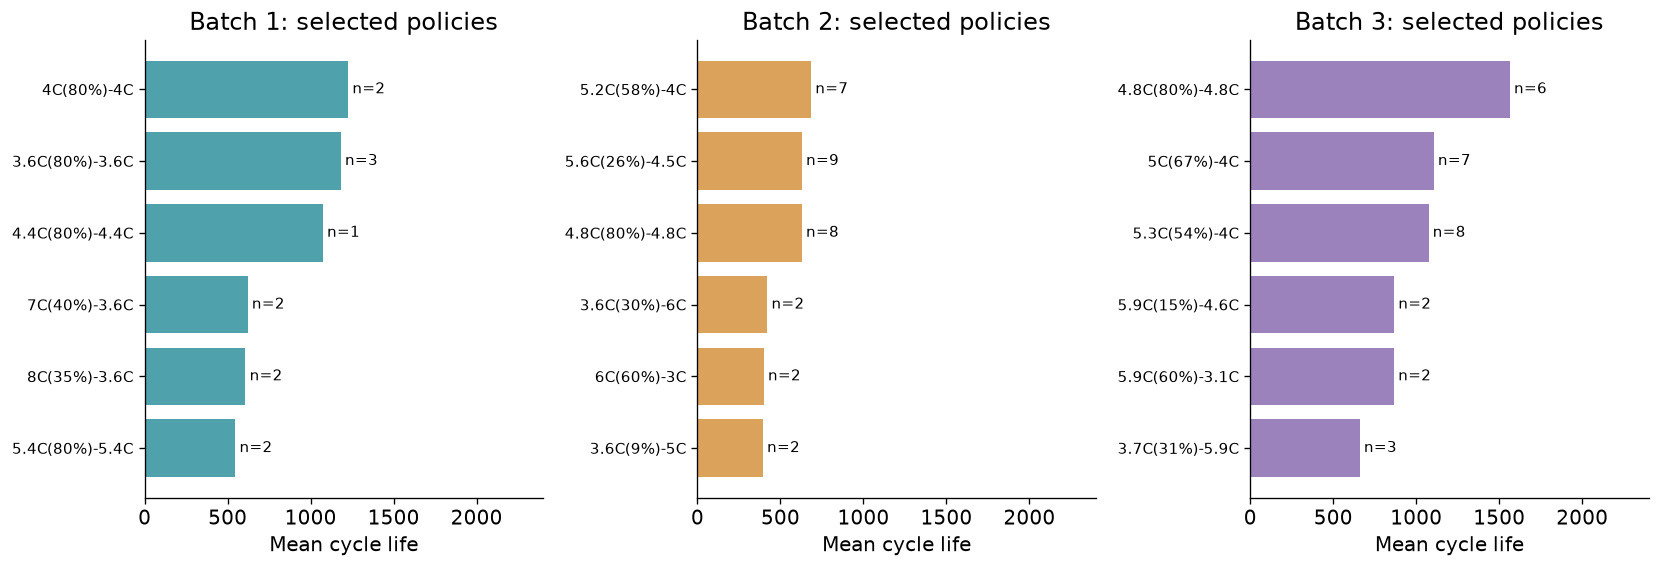

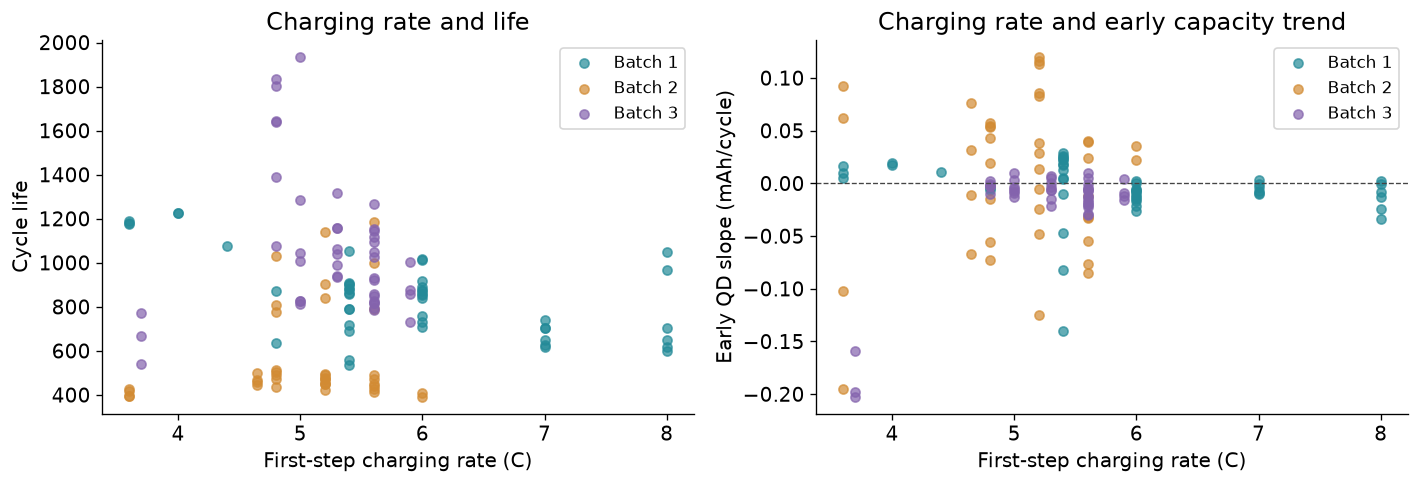

In [5]:
policies=feat.groupby(['batch','policy']).cycle_life.agg(['mean','std','count']).reset_index()
policies.to_csv(BASE/'policy_summary.csv',index=False)
fig,axes=plt.subplots(1,3,figsize=(14,4.9))
for bi,ax in enumerate(axes,1):
    s=policies[policies.batch==bi].sort_values('mean')
    chosen=pd.concat([s.head(3),s.tail(3)]).drop_duplicates('policy').sort_values('mean')
    ax.barh(range(len(chosen)),chosen['mean'],color=palette[bi],alpha=.8)
    for j,row in enumerate(chosen.itertuples()):
        ax.text(row.mean+25,j,f'n={row.count}',va='center',fontsize=9)
    ax.set(yticks=range(len(chosen)),yticklabels=chosen.policy,xlabel='Mean cycle life',title=f'Batch {bi}: selected policies',xlim=(0,2400))
    ax.tick_params(axis='y',labelsize=9)
fig.tight_layout();show_save(fig,'q4_charge_policy.png')

# Early capacity slope is an EDA measure only, not a third engineered model feature.
speed=[]
for cid,s in df[df.cycle.between(2,100)].groupby('cell_id'):
    q=valid_capacity(s);valid=q.notna()
    slope=np.polyfit(s.loc[valid,'cycle'],q[valid],1)[0]*1000
    speed.append({'cell_id':cid,'early_QD_slope_mAh_per_cycle':slope})
eda_speed=feat[['cell_id','batch','C1','C2','SOC_switch','cycle_life']].merge(pd.DataFrame(speed),on='cell_id')
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
for bi in [1,2,3]:
    s=eda_speed[eda_speed.batch==bi]
    axes[0].scatter(s.C1,s.cycle_life,color=palette[bi],label=f'Batch {bi}',alpha=.7,s=30)
    axes[1].scatter(s.C1,s.early_QD_slope_mAh_per_cycle,color=palette[bi],label=f'Batch {bi}',alpha=.7,s=30)
axes[0].set(xlabel='First-step charging rate (C)',ylabel='Cycle life',title='Charging rate and life')
axes[1].axhline(0,color='#444444',ls='--',lw=.8)
axes[1].set(xlabel='First-step charging rate (C)',ylabel='Early QD slope (mAh/cycle)',title='Charging rate and early capacity trend')
for ax in axes:ax.legend(fontsize=10)
fig.tight_layout();show_save(fig,'q4_current_and_fade.png')
eda_speed.to_csv(BASE/'charging_fade_eda_only.csv',index=False)
print('Early C1 vs QD slope r:',round(eda_speed.C1.corr(eda_speed.early_QD_slope_mAh_per_cycle),3))

### 5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**확인 목적:** 초기 2~100사이클 측정값의 관계가 배치마다 유지되는지 확인한다. **신호 분석 대상 115개 셀**로 계산했다. 상관계수는 -1~1이며 절댓값이 클수록 직선 관계가 강하지만 원인을 증명하지는 않는다.



**확인한 내용과 해석:** ΔQ 로그 분산은 세 배치에서 모두 강한 음의 관계다. 초기 평균 충전 시간은 Batch 1 **+0.570**, Batch 2 **-0.917**, Batch 3 **+0.598**로 방향이 달라진다. 온도와 IR도 관계가 배치마다 다르므로 전체 상관만 보고 변수의 의미를 단정하기 어렵다.



평균·최대 온도는 **r=+0.865**, 두 ΔQ 변수는 **r=-0.959**다. 비슷한 정보를 함께 넣으면 설명이 겹친다. 이런 입력 간 강한 관계를 다중공선성이라고 한다.

**시사점:** ΔQ 분산을 우선 후보로 두고 두 번째 변수의 추가 효과는 Batch 1의 MAPE로 다시 비교한다. 온도·IR은 주 실험에서 보류하되 낮은 상관만으로 항상 쓸모없다고 결론 내리지는 않는다. 겹치는 변수를 다룰 수 있는 Ridge를 기준 모델로 정한다.


                 Batch 1  Batch 2  Batch 3    All
mean_QD            0.250   -0.333    0.292 -0.501
mean_IR            0.224   -0.626    0.201 -0.379
mean_Tavg         -0.173    0.425   -0.039  0.330
mean_Tmax         -0.163    0.019   -0.138  0.023
mean_chargetime    0.570   -0.917    0.598  0.198
C1                -0.235    0.191   -0.039  0.038
C2                -0.235   -0.116   -0.109 -0.141
SOC_switch        -0.175    0.116    0.532  0.132
dq_log_variance   -0.827   -0.902   -0.742 -0.857
dq_band_gap        0.829    0.885    0.747  0.818
Tavg vs Tmax: 0.865
Two engineered features: -0.959


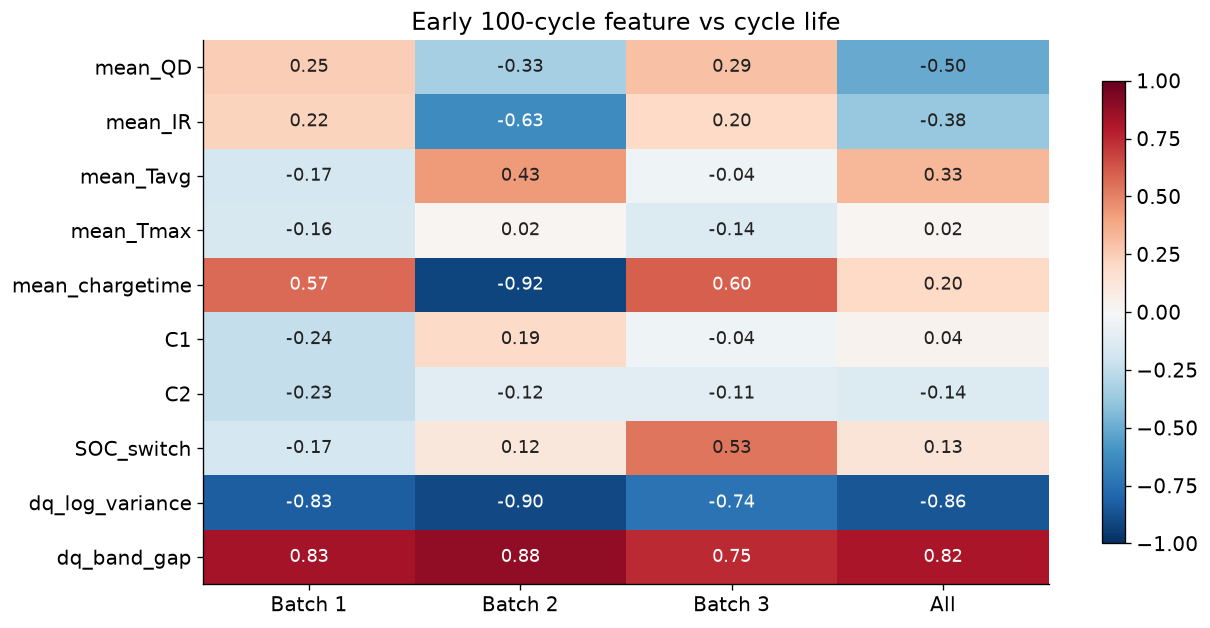

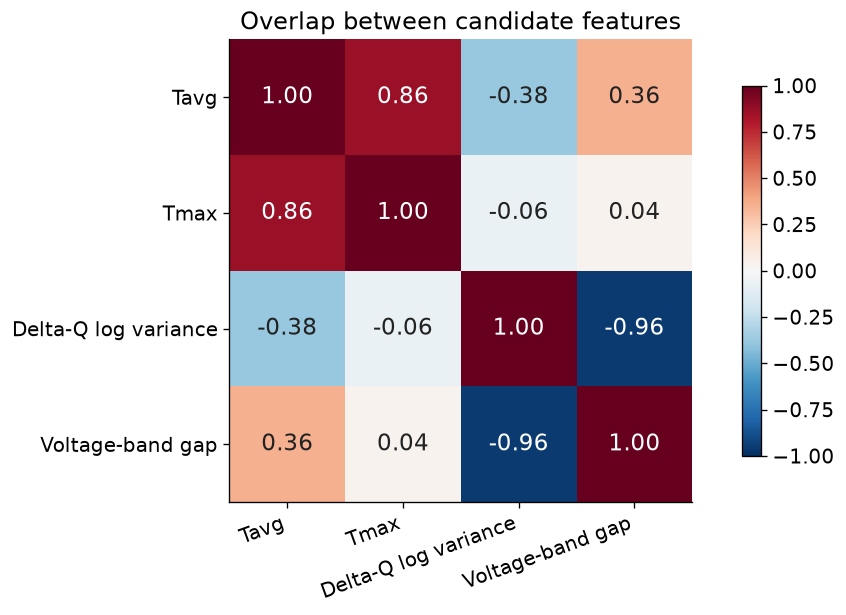

In [6]:
signals=['mean_QD','mean_IR','mean_Tavg','mean_Tmax','mean_chargetime','C1','C2','SOC_switch','dq_log_variance','dq_band_gap']
correlations=pd.DataFrame({f'Batch {bi}':model_feat[model_feat.batch==bi][signals].corrwith(model_feat[model_feat.batch==bi].cycle_life) for bi in [1,2,3]})
correlations['All']=model_feat[signals].corrwith(model_feat.cycle_life)
correlations.to_csv(BASE/'correlations.csv',index_label='signal')
fig,ax=plt.subplots(figsize=(10.8,5.4))
im=ax.imshow(correlations,cmap='RdBu_r',vmin=-1,vmax=1,aspect='auto')
ax.set(xticks=range(4),xticklabels=correlations.columns,yticks=range(len(signals)),yticklabels=signals,title='Early 100-cycle feature vs cycle life')
for i in range(len(signals)):
    for j in range(4):
        val=correlations.iloc[i,j];ax.text(j,i,f'{val:.2f}',ha='center',va='center',color='white' if abs(val)>.55 else '#222222',fontsize=11)
fig.colorbar(im,ax=ax,shrink=.85);fig.tight_layout();show_save(fig,'q5_correlations.png')
overlap=model_feat[['mean_Tavg','mean_Tmax','dq_log_variance','dq_band_gap']].corr()
fig,ax=plt.subplots(figsize=(9,5.3))
im=ax.imshow(overlap,cmap='RdBu_r',vmin=-1,vmax=1)
labels=['Tavg','Tmax','Delta-Q log variance','Voltage-band gap']
ax.set(xticks=range(4),yticks=range(4),xticklabels=labels,yticklabels=labels,title='Overlap between candidate features')
plt.setp(ax.get_xticklabels(),rotation=20,ha='right')
for i in range(4):
    for j in range(4):
        val=overlap.iloc[i,j];ax.text(j,i,f'{val:.2f}',ha='center',va='center',color='white' if abs(val)>.55 else '#222222',fontsize=14)
fig.colorbar(im,ax=ax,shrink=.8);fig.tight_layout();show_save(fig,'q5_feature_overlap.png')
print(correlations.round(3).to_string())
print('Tavg vs Tmax:',round(model_feat.mean_Tavg.corr(model_feat.mean_Tmax),3))
print('Two engineered features:',round(model_feat.dq_log_variance.corr(model_feat.dq_band_gap),3))

## 모델 설계 전략

### 1. Feature Engineering: EDA에서 후보 변수를 정하기

기본 입력은 원래 충전 정책의 **C1·C2·전환 SOC**와 **초기 평균 충전 시간**이다. 정책을 단계별 숫자로 풀고 원래 측정값은 대표값으로 정리한다. 추가 파생변수 후보는 **두 개만** 사용한다.

| 파생변수 | 만드는 방법 | 만든 이유 |
|---|---|---|
| **1. ΔQ 로그 분산** (`dq_log_variance`) | ΔQ=Q100-Q10의 분산을 계산한 뒤 log10 적용 | 비슷한 초기 용량 속에서 전압별 변화 분포가 수명과 연결됨. 로그는 값의 넓은 크기 차이를 줄여 표현. |
| **2. 전압 구간별 ΔQ 차이** (`dq_band_gap`) | 2.8~3.1 V 평균 ΔQ에서 2.0~2.5 V 평균 ΔQ를 뺌 | 전체 분산이 놓칠 수 있는 변화 위치의 차이를 담아보기 위한 후보. 단위 Ah. |

전압 구간은 곡선의 위치 차이를 확인하기 위해 정한 탐색 후보다. 특정 열화 원인을 뜻한다고 확정하지 않았다. DAY 2 비교 전에 두 정의를 고정하고 Test 성능을 보고 바꾸지 않는다.



**관계와 추가 성능을 구분:** 두 후보는 수명과 관계가 있지만 서로의 상관도 -0.959로 높다. 새 변수의 상관이 높아도 이미 있는 변수를 보완하지 못할 수 있다.

#### 참고 탐색: 파생변수를 추가했을 때 실제 오차는 줄었는가?

아래 결과는 **세 배치의 115개 셀을 사용한 DAY 1 탐색 실험**이다. 같은 Ridge와 같은 분할로 입력만 바꿔 비교했다. 셀 분할은 5-fold를 3회 반복했고, 배치 제외는 두 배치로 학습해 남은 배치를 예측했다. 제한 강도는 각 학습 자료 안의 3-fold에서 0.01, 0.1, 1, 10, 100을 비교했다. 빈 값 대치·크기 조정과 예측 최소값 1사이클을 모든 조합에 동일하게 적용했다.

**이 수치는 DAY 2의 Train / Valid / Test 성능이 아니다.** MAE는 평균 절대 오차이며 단위는 사이클이다. DAY 2의 주 지표 MAPE와 구분한다.



| 입력 변수 | 셀을 나눈 평가 MAE | 배치를 제외한 평가 MAE |
|---|---:|---:|
| 충전 조건만 | 232.5 | 354.5 |
| 조건 + 변수 1: ΔQ 로그 분산 | 115.2 | 194.4 |
| 조건 + 변수 2: 전압 구간 차이 | 125.7 | 262.6 |
| 조건 + 두 변수 모두 | 119.3 | 203.4 |

**확인한 사실:** 분산 추가 시 셀 분할 MAE가 232.5→115.2로 약 50.5% 줄었다. 두 변수를 함께 넣으면 119.3로 조금 나빠졌다.



배치 제외에서도 두 변수의 평균 MAE 203.4는 분산만 넣은 194.4보다 나빴다. Batch 2에서는 두 번째 변수의 일부 이득이 있지만 Batch 1·3에서는 없었다. 또한 Batch 1 제외 평가에서는 분산을 추가한 모델 자체가 조건만 사용한 모델보다 나빴다. 새 배치의 예측이 항상 좋아진다고 단정할 수 없다.

**DAY 1에서 세운 전략 → DAY 2에서 확인한 결과:** ΔQ 로그 분산을 우선 후보로 두고,
두 번째 변수의 추가 효과는 Batch 1 개발 자료의 MAPE로 확인했다.
앞의 MAE 실험은 Batch 2·3도 사용한 탐색이며 최종 후보 선택 점수로 사용하지 않았다.
DAY 2에서 같은 SVR·로그 타깃의 입력 조합을 비교한 결과 로그 분산만 사용하면 선택용 CV 8.30%,
기본 입력+두 파생변수는 11.90%였다. 최종적으로 로그 분산 하나를 선택했다.
각 입력 조합의 설정도 따로 선택한 결과이므로 변수 하나의 순수한 효과를 증명하는 비교는 아니다.

| 변수 | DAY 1 설계 | DAY 2 최종 처리와 이유 |
|---|---|---|
| C1·C2·전환 SOC·초기 충전 시간 | 기본 비교 입력 | 후보로 구현·비교했으나 최종 SVR은 로그 분산만 사용한 조합이 더 낮은 CV여서 포함하지 않음 |
| ΔQ 로그 분산 | 우선 후보 | 최종 입력으로 선택. 개발 자료의 선택용 CV 8.30% |
| 전압 구간별 ΔQ 차이 | 추가 비교 후보 | 강한 중복 관계와 입력 조합 비교를 확인. 이번 최종 모델에서는 제외 |
| 온도·IR·평균 QD | 주 비교 보류 | 아래 변수별 EDA·품질 근거로 후보 범위를 제한. 성능 열등을 검증한 것은 아님 |
| 셀 ID·barcode·channel ID·batch 번호 | 입력 제외 | 식별값과 평가 구분용 |
| 마지막 용량·전체 기록 길이·Knee | 입력 제외 | 100사이클 이후의 미래 정보 |

### 보류한 변수와 그 근거

상관계수는 모델 대상 115개 셀에서 계산한 배치별 Pearson 상관이다.
전체 배치 EDA를 이미 본 상태에서 정한 후보 범위이며, 완전한 블라인드 Test는 아니다.
최종 후보 선택은 Batch 1 개발 자료로 한정했다.

| 변수 | 실제로 확인한 내용 | 이번 비교에서 보류한 이유 |
|---|---|---|
| 평균·최대 온도 (`mean_Tavg`, `mean_Tmax`) | 두 변수의 상관이 +0.865. 평균 온도와 수명의 상관은 Batch 1 −0.173, Batch 2 +0.425, Batch 3 −0.039 | 온도끼리 정보가 겹치고 수명과의 관계도 배치마다 달라, 작은 개발 표본에서 ΔQ와 충전 조건을 먼저 비교 |
| 평균 IR (`mean_IR`) | 평균 IR과 수명의 상관은 +0.224, −0.626, +0.201. 정리 후 Batch 2의 6개 셀에서 평균 IR이 결측이며 Batch 1에는 결측 없음 | 관계 방향과 측정 가용성이 배치마다 다름. IR을 추가한 후보와 결측 대치 효과는 후속 개발 실험으로 남김 |
| 초기 평균 방전 용량 (`mean_QD`) | 평균 QD와 수명의 상관은 +0.250, −0.333, +0.292. 초기 용량이 유지되거나 증가하는 셀도 많음 | 초기 평균값 하나의 배치 간 관계가 일정하지 않아, 전압별 변화인 ΔQ를 우선 검증 |

**보류는 성능이 나빠서 제외했다는 뜻이 아니다.** 이 변수들을 추가한 모델의 CV는 이번에 비교하지 않았다.
상관이 작거나 방향이 다르더라도 비선형 관계·다른 변수와의 조합은 도움이 될 수 있다.
후속 실험에서는 Batch 1 개발 자료에서 하나씩 추가해 같은 그룹 분할로 비교해야 한다.
근거: [배치별 상관 표](../results/correlations.csv), [초기 측정 품질 표](../results/input_quality.csv).


   evaluation              model    MAE   RMSE
      Cell CV      Charging only 232.46 301.74
      Cell CV + Delta-Q variance 115.18 161.70
      Cell CV + Voltage-band gap 125.68 180.31
      Cell CV    + Both features 119.25 167.32
Batch holdout      Charging only 354.46 418.49
Batch holdout + Delta-Q variance 194.38 261.81
Batch holdout + Voltage-band gap 262.58 377.38
Batch holdout    + Both features 203.37 284.76
model  + Both features  + Delta-Q variance  + Voltage-band gap  Charging only
batch                                                                        
1               291.35              271.48              424.34         223.15
2               143.94              150.21              166.13         412.43
3               182.14              168.06              211.03         416.12


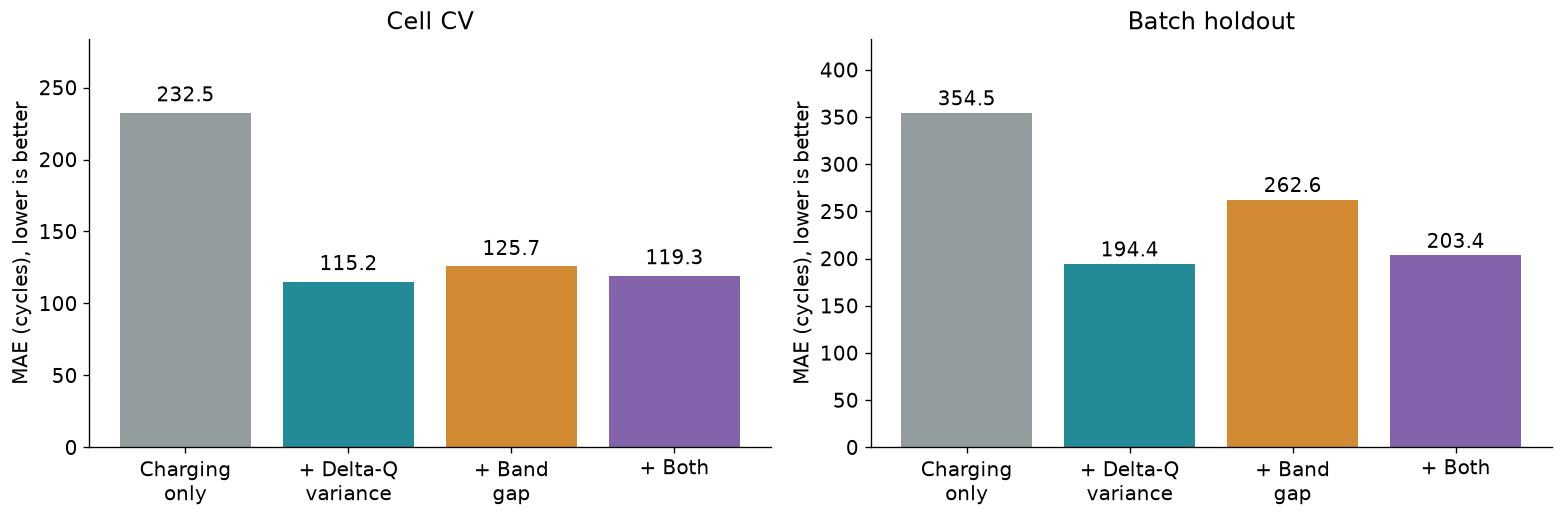

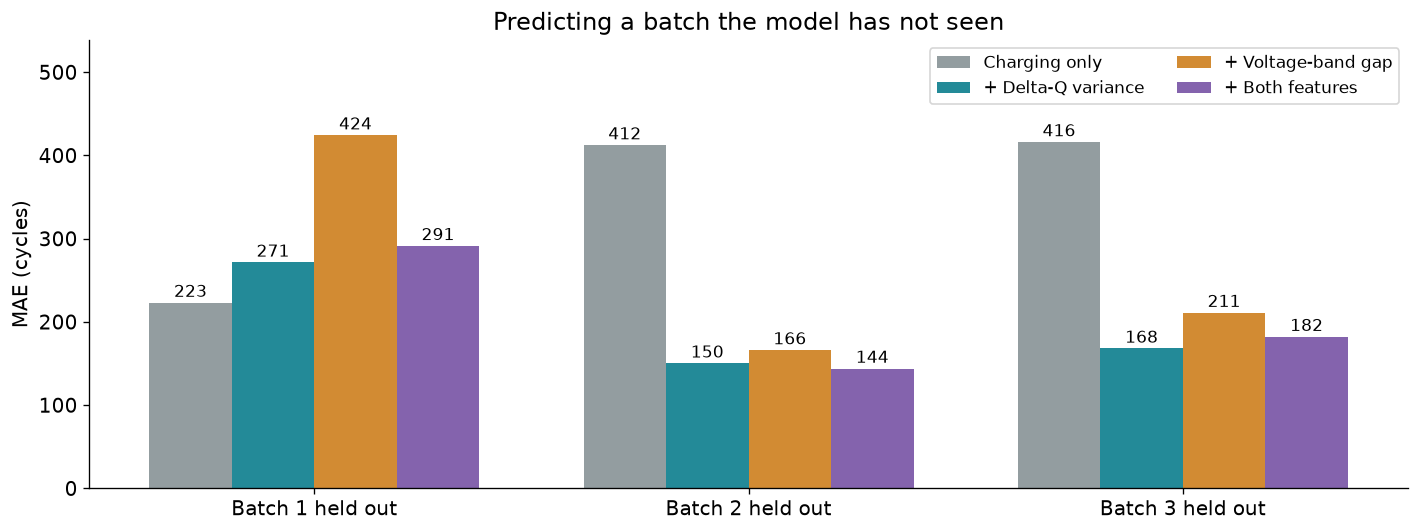

In [7]:
# Fix the feature groups, folds, Ridge model family and alpha candidates before comparison.
base_features=['C1','C2','SOC_switch','mean_chargetime']
feature_sets={'Charging only':base_features,
              '+ Delta-Q variance':base_features+['dq_log_variance'],
              '+ Voltage-band gap':base_features+['dq_band_gap'],
              '+ Both features':base_features+['dq_log_variance','dq_band_gap']}
def tuned_ridge(X,y,seed):
    pipe=make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),Ridge())
    search=GridSearchCV(pipe,{'ridge__alpha':[.01,.1,1,10,100]},scoring='neg_mean_absolute_error',
                        cv=KFold(3,shuffle=True,random_state=seed),n_jobs=1)
    search.fit(X,y);return search.best_estimator_,search.best_params_['ridge__alpha']
pred_rows=[]
for seed in [42,43,44]:
    for fold,(train,test) in enumerate(KFold(5,shuffle=True,random_state=seed).split(model_feat),1):
        for label,columns in feature_sets.items():
            model,alpha=tuned_ridge(model_feat.iloc[train][columns],model_feat.iloc[train].cycle_life,seed)
            raw_preds=model.predict(model_feat.iloc[test][columns])
            preds=np.maximum(1,raw_preds)  # Same physical lower bound for every feature set.
            for idx,pred,raw_pred in zip(test,preds,raw_preds):
                row=model_feat.iloc[idx]
                pred_rows.append({'evaluation':'Cell CV','seed':seed,'fold':fold,'batch':int(row.batch),'cell_id':row.cell_id,'model':label,
                                  'true_life':row.cycle_life,'pred_life':float(pred),'raw_prediction':float(raw_pred),'absolute_error':abs(row.cycle_life-pred),'alpha':alpha})
for held in [1,2,3]:
    train=model_feat[model_feat.batch!=held];test=model_feat[model_feat.batch==held]
    for label,columns in feature_sets.items():
        model,alpha=tuned_ridge(train[columns],train.cycle_life,42)
        raw_preds=model.predict(test[columns])
        preds=np.maximum(1,raw_preds)
        for (_,row),pred,raw_pred in zip(test.iterrows(),preds,raw_preds):
            pred_rows.append({'evaluation':'Batch holdout','seed':42,'fold':held,'batch':held,'cell_id':row.cell_id,'model':label,
                              'true_life':row.cycle_life,'pred_life':float(pred),'raw_prediction':float(raw_pred),'absolute_error':abs(row.cycle_life-pred),'alpha':alpha})
predictions=pd.DataFrame(pred_rows);predictions.to_csv(BASE/'model_predictions.csv',index=False)
scores=predictions.groupby(['evaluation','model'],sort=False).apply(lambda g:pd.Series({
    'MAE':g.absolute_error.mean(),'RMSE':np.sqrt(np.mean((g.true_life-g.pred_life)**2))}),include_groups=False).reset_index()
scores.to_csv(BASE/'feature_performance.csv',index=False)
batch_scores=predictions[predictions.evaluation=='Batch holdout'].groupby(['batch','model']).absolute_error.mean().unstack()
batch_scores.to_csv(BASE/'batch_holdout_performance.csv')
order=list(feature_sets)
fig,axes=plt.subplots(1,2,figsize=(13.2,4.5))
for ax,ev in zip(axes,['Cell CV','Batch holdout']):
    vals=scores[scores.evaluation==ev].set_index('model').reindex(order).MAE
    bars=ax.bar(range(4),vals,color=['#939da0','#238a98','#d28b33','#8463ad'])
    for bar,val in zip(bars,vals):ax.text(bar.get_x()+bar.get_width()/2,val+8,f'{val:.1f}',ha='center',fontsize=12)
    ax.set(xticks=range(4),xticklabels=['Charging\nonly','+ Delta-Q\nvariance','+ Band\ngap','+ Both'],ylabel='MAE (cycles), lower is better',title=ev,ylim=(0,max(vals)*1.22))
fig.tight_layout();show_save(fig,'fe_performance.png')
fig,ax=plt.subplots(figsize=(12,4.6))
x=np.arange(3);width=.19
for j,label in enumerate(order):
    vals=batch_scores[label].reindex([1,2,3]);bars=ax.bar(x+(j-1.5)*width,vals,width,label=label,color=['#939da0','#238a98','#d28b33','#8463ad'][j])
    for bar,val in zip(bars,vals):ax.text(bar.get_x()+bar.get_width()/2,val+7,f'{val:.0f}',ha='center',fontsize=10)
ax.set(xticks=x,xticklabels=['Batch 1 held out','Batch 2 held out','Batch 3 held out'],ylabel='MAE (cycles)',title='Predicting a batch the model has not seen')
ax.legend(fontsize=10,ncol=2);ax.set_ylim(0,batch_scores.max().max()*1.27)
fig.tight_layout();show_save(fig,'fe_batch_holdout.png')
print(scores.round(2).to_string(index=False));print(batch_scores.round(2).to_string())

### 2. Regression vs Classification: 회귀 선택과 Target Variable

논문은 회귀와 분류를 모두 진행했다. 이번 과제는 **Regression(회귀) 하나를 선택**한다.

| 항목 | Regression | Classification |
|---|---|---|
| 질문 | 최종 수명이 몇 사이클인가? | 정한 기준보다 오래 가는가? |
| 목표값 | 실제 `cycle_life` | 장수명 / 단수명 범주 |
| 이번 결정 | **선택** | 방법 설명에만 포함 |

**선택 이유:** 이번 질문은 초기 ΔQ 정보가 수명 예측을 얼마나 개선하는가다. 실제 수명 차이를 유지하는 회귀가 목적에 맞으며, 과제와 논문의 MAPE 기준으로 비교할 수 있다.

**Target Variable:** 최종 수명 사이클 수인 `cycle_life`. **예측 시점:** 100사이클 종료 시점. 결측 목표값과 종료 전 중단된 기록을 확정 수명으로 대신하지 않는다.

기존 탐색은 원래 수명값을 예측했다. DAY 2에서는 원래 수명과 로그 수명을 예측하는 방법을 Batch 1 안에서 비교할 수 있다. 로그 수명으로 학습하더라도 예측을 원래 사이클 수로 되돌린 뒤 MAPE를 계산한다. 목표의 의미는 최종 수명으로 유지되며, 입력 파생변수를 세 개로 늘리는 것이 아니다. 논문은 로그 수명을 ElasticNet으로 예측한다. [원 논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)


### 3. Modeling Strategy: EDA 전략과 DAY 2 구현·평가 연결

#### EDA → 전략 → 실제 구현

| EDA에서 확인한 내용 | 세운 전략 | DAY 2에서 실제로 수행한 내용 |
|---|---|---|
| 초기 전체 용량이 비슷해도 수명 차이가 있고, ΔQ 로그 분산은 배치마다 수명과 음의 관계 | 초기 전압별 변화를 적은 변수로 요약 | 3단계에서 ΔQ100−10과 두 파생변수 생성, 10단계에서 입력 조합별 CV 비교 |
| 두 ΔQ 변수의 상관 −0.959 | 함께 넣는 것이 더 좋은지 비교 | 변수 두 개를 모두 넣은 조합보다 분산 하나의 SVR CV가 낮아 단일 입력 선택 |
| 충전 조건 하나로 수명 순서를 설명하기 어려움 | C1·C2·전환 SOC·초기 시간을 후보로 구성 | 기본 입력과 ΔQ를 포함한 5개 조합 비교 |
| Batch 1 모델 셀은 36개, 개발 셀은 29개 | 작은 표본에 맞게 후보·복잡도 제한 | Ridge·ElasticNet·RBF SVR·얕은 Random Forest와 제한된 설정 비교 |
| 같은 충전 프로토콜의 셀이 반복됨 | 프로토콜 그룹으로 분할 | 그룹 Hold-out, 안쪽·바깥 GroupKFold; CV 분할 23건의 셀·프로토콜 중복 0개 |
| Batch 2는 단수명, Batch 3는 장수명 비중이 높음 | 개발 점수와 배치 간 성능을 구분 | 고정 모델로 Batch 2 필수 Test와 Batch 3 추가 Test, 범위별 오류 진단 |
| 결측·미완료·잡음 기록이 있음 | 품질 기준과 전처리 기준을 명시 | 1단계 제외 기록, Pipeline 내부에서 학습 부분의 중앙값 대치·표준화 |

#### 후보 모델과 최종 선택

| 후보 | 선정 이유 | DAY 2 실행 결과 |
|---|---|---|
| Ridge | 작은 표본과 겹치는 변수를 다루는 선형 기준 모델 | 후보로 구현·비교 |
| ElasticNet | 정규화와 일부 변수 영향 축소의 효과 확인 | 후보로 구현·비교 |
| RBF SVR | 입력과 수명이 직선으로만 연결되지 않을 가능성 확인 | 후보로 구현·비교하고 최종 선택 |
| 얕은 Random Forest | 충전 조건 조합과 구간별 관계 확인 | 후보로 구현·비교 |

입력 5조합과 원래/로그 타깃 및 모델 설정을 포함한 340개 후보를 개발 자료에서 비교했다.
최종 모델은 `dq_log_variance` 하나를 사용하는 RBF SVR이다.
설정은 `C=1`, `epsilon=0.01`, `gamma=0.1`이며 로그 타깃 예측을 `exp`로 역변환한다.
같은 개발 분할에서 선택용 CV가 가장 낮은 조합을 선택했다. 이번 후보 범위 안에서 최적이라는 의미다.

#### 필수 학습·검증·테스트 구조

**Batch 1만 개발·학습에 사용하고 Batch 2는 필수 Test, Batch 3는 고정 모델의 추가 Test로 사용했다.**
프로토콜 그룹은 C1·C2·전환 SOC 조합이다. 그룹 20%를 Hold-out으로 남겼고 seed=42를 고정했다.
Hold-out이라는 이름만으로 같은 프로토콜의 중복을 막을 수 없어 실제 그룹 중복을 점검했다.

| 구분 | 셀 수 | 프로토콜 수 | 실제 역할 |
|---|---:|---:|---|
| Batch 1 개발 | 29 | 16 | 후보 비교·중첩 CV·최종 학습 |
| Batch 1 Hold-out | 7 | 4 | 고정 모델의 Valid |
| Batch 2 | 39 | 9 | 필수 최종 Test |
| Batch 3 | 40 | 8 | 같은 모델의 추가 Test |

개발·Hold-out 사이의 셀·프로토콜 중복은 각각 0개다.
최종 모델은 개발 29개로 학습하고 고정하여 Valid·Batch 2·Batch 3에는 예측만 했다.
전체 Batch 1 36개로 재학습하거나 Test 성능으로 입력·설정을 다시 선택하지 않았다.
결측 대치·표준화는 Pipeline 안에서 각 학습 부분으로만 계산했다.

### 세 가지 CV·평가 값을 구분하기

| 값 | 데이터와 역할 | 결과 |
|---|---|---:|
| 선택용 CV | 개발 29개 전체에서 같은 안쪽 3-fold로 후보를 비교. 최종 조합을 고르는 점수 | 8.30% |
| Train (Batch 1 CV) | 바깥 5-fold마다 안쪽 3-fold로 후보를 다시 선택하고, 선택에 쓰지 않은 바깥 셀을 평가한 평균 | 15.40% |
| Valid / Test | 개발 29개로 학습한 최종 SVR을 고정하고 새 셀을 예측 | Valid 11.87%, Batch 2 28.08% |

**Train 15.40%는 최종 SVR 하나의 고정 설정 CV가 아니라 모델·입력·설정을 고르는 전체 과정의 검증이다.**
바깥 폴드의 선택 모델은 SVR, SVR, Ridge, Random Forest, Ridge였고,
검증 MAPE는 각각 7.20%, 9.82%, 7.25%, 14.30%, 38.43%였다.
검증 셀이 서로 다르므로 이 다섯 점수만으로 모델 순위를 정하지 않는다.
최종 선택은 개발 29개의 동일한 선택용 CV 분할에서 비교한 결과로 결정했다.

MAPE가 낮을수록 좋다. 선택용 CV 8.30%를 새 배치 성능으로 제시하지 않는다.
바깥 CV 편차가 크므로 선택이 표본 구성에 민감했음을 함께 설명한다.

#### Performance Reporting: 최신 DAY 2 결과

`MAPE(%) = mean(abs((실제 수명 − 예측 수명) / 실제 수명)) × 100`

아래는 DAY 2 실행 결과와 같은 표다. 이 DAY 1 노트북의 EDA·분할 코드에서 계산한 성능은 아니다.
원래 계획표를 최신 결과로 갱신했다.

| 구분 | 추가 비교 | MAPE (%) | 비고 |
|---|---|---:|---|
| Train (Batch 1 CV) | | 15.40 | 개발 29개, 바깥 5-fold 중첩 그룹 CV 평균 |
| Valid (Batch 1 Hold-out) | | 11.87 | 고정 Hold-out 7개 |
| Test (Batch 2) | | 28.08 | 고정 모델, 39개 전체 |
| | Gap (Train-Valid) | −3.53 | Valid − Train, %p |
| | Gap (Valid-Test) | +16.21 | Batch 2 − Valid, %p |
| | Gap (Target-Test) | +18.98 | Batch 2 − 9.1, %p |
| Test (Batch 3) | | 18.85 | 동일한 고정 모델, 40개 전체 |
| | Gap (Batch2-Batch3) | −9.23 | Batch 3 − Batch 2, %p |
| | Gap (Target-Test) | +9.75 | Batch 3 − 9.1, %p |

**Gap은 뒤 평가의 오차가 증가하면 양수다.** Train-Valid는 `Valid − Train`,
Valid-Test는 `Batch 2 − Valid`, Target-Test는 `Test − 9.1`,
Batch2-Batch3는 `Batch 3 − Batch 2`다. 지표는 %, 차이는 %p다.
Train-Valid는 −3.53%p지만 검증 셀·프로토콜과 학습 표본 수가 달라 과적합이 없다고 확정하지 않는다.
Train CV는 선택 과정, Valid는 고정 SVR의 평가라는 범위 차이도 있다.
Batch 2는 Valid보다 16.21%p 높고 논문 기준보다 18.98%p 높아 일반화와 목표 성능에 한계가 있었다.
분류 지표 F1·Accuracy와 분류 기준 4.9%는 이번 회귀 표에 적용하지 않는다.

#### 한계와 최종 판단

앞의 232.5→115.2사이클은 DAY 1의 탐색 MAE이며, 최종 Test MAPE 28.08%와 구분한다.
전체 배치 EDA를 이미 수행했으므로 완전히 블라인드한 Test라고 주장하지 않는다.
그 후 최종 후보 선택·설정 조정은 Batch 1 개발 자료로 한정했다.
논문과 제공 배치·정제·분할이 동일한 조건은 아니므로 완전한 논문 재현이라고 설명하지 않는다.

배치별 수명 분포와 개발 수명 범위 차이는 큰 오류의 원인 후보다.
이를 확인하려고 실제-예측 그림과 셀별 오류를 분석했으며 어려운 셀을 제거해 점수를 높이지 않았다.
ESS에서는 검사·유지보수 우선순위의 보조 정보로 활용을 제안할 수 있지만,
실험실의 단일 셀 결과를 현장 BESS에 직접 적용하려면 운전 조건·팩 수준·불확실성 검증이 필요하다.
자세한 오류 분석과 ESS 해석은 [프로젝트 README](../README.md)에 있다.


## DAY 2와 같은 분할을 확인하는 준비 코드

아래 셀은 EDA 자료의 분할만 생성한다. 이 셀 자체는 모델 학습이나 Test 점수를 계산하지 않는다.
최종 모델 개발·평가는 DAY 2 노트북에서 이미 완료했으며 결과는 위 최신 표를 따른다.
Batch 3의 `EDA-only` 표기는 이 준비 코드의 역할이고, DAY 2에서는 고정 모델로 추가 평가했다.


In [8]:
# Split preparation only: no DAY 2 models are trained and Batch 2 is not scored here.
from sklearn.model_selection import GroupShuffleSplit,GroupKFold
split_features=feat[feat.model_eligible].copy()
split_features['protocol_group']=split_features.apply(
    lambda r:f'{r.C1:g}C({r.SOC_switch:g}%)-{r.C2:g}C',axis=1)
b1=split_features[split_features.batch==1].copy().reset_index(drop=True)
development_idx,valid_idx=next(GroupShuffleSplit(
    n_splits=1,test_size=.2,random_state=42).split(b1,groups=b1.protocol_group))
development=b1.iloc[development_idx].copy().reset_index(drop=True)
valid=b1.iloc[valid_idx].copy()
assert not set(development.cell_id)&set(valid.cell_id)
assert not set(development.protocol_group)&set(valid.protocol_group)
development['partition']='Batch1-development-CV'
valid['partition']='Batch1-holdout-Valid'
development['cv_holdout_fold']=0
for fold,(fit_idx,cv_idx) in enumerate(GroupKFold(n_splits=5).split(
        development,groups=development.protocol_group),1):
    assert not set(development.iloc[fit_idx].protocol_group)&set(development.iloc[cv_idx].protocol_group)
    development.loc[cv_idx,'cv_holdout_fold']=fold
valid['cv_holdout_fold']=pd.NA
test=split_features[split_features.batch==2].copy()
test['partition']='Batch2-final-Test';test['cv_holdout_fold']=pd.NA
reference=split_features[split_features.batch==3].copy()
reference['partition']='Batch3-EDA-only';reference['cv_holdout_fold']=pd.NA
manifest=pd.concat([development,valid,test,reference],ignore_index=True)
manifest['cv_holdout_fold']=manifest['cv_holdout_fold'].astype('Int64')
manifest=manifest[['cell_id','batch','protocol_group','partition','cv_holdout_fold']]
manifest.to_csv(BASE/'DAY2-split-manifest.csv',index=False)
summary=manifest.groupby(['partition','batch']).agg(
    cells=('cell_id','size'),protocols=('protocol_group','nunique')).reset_index()
summary.to_csv(BASE/'DAY2-split-summary.csv',index=False)
print('Split preparation only; completed model evaluation is in the DAY 2 notebook.')
print(summary.to_string(index=False))
print('Development/Valid overlap: cell IDs = 0; protocols = 0.')


Split preparation only; completed model evaluation is in the DAY 2 notebook.
            partition  batch  cells  protocols
Batch1-development-CV      1     29         16
 Batch1-holdout-Valid      1      7          4
    Batch2-final-Test      2     39          9
      Batch3-EDA-only      3     40          8
Development/Valid overlap: cell IDs = 0; protocols = 0.
